Challenge 1

In [1]:
import rasterio
from rasterio.mask import mask 

In [2]:
file_population = 'germany_population_reprojected.tif'
file_elevation = 'germany_elevation_reprojected_resampled.tif'

In [3]:
from shapely.geometry import Point
import geopandas as gpd

berlin = Point(13.40500, 52.52000)
munich = Point(11.58200, 48.13510)

crs = 'EPSG:25832'

In [4]:
gdf_berlin = gpd.GeoDataFrame([berlin], columns = ['geometry'])
gdf_berlin.crs = 4326
gdf_berlin = gdf_berlin.to_crs(crs)

gdf_munich = gpd.GeoDataFrame([munich], columns = ['geometry'])
gdf_munich.crs = 4326
gdf_munich = gdf_munich.to_crs(crs)

gdf_munich

,geometry
0,POINT (692095.145 5334540.636)


In [5]:
city_areas = [
    ('Berlin', '500m', gdf_berlin.buffer(500)),
    ('Berlin', '1000m', gdf_berlin.buffer(1000)),
    ('Berlin', '5000m', gdf_berlin.buffer(5000)),
    ('Berlin', '10000m', gdf_berlin.buffer(10000)),
    ('Munich', '500m', gdf_munich.buffer(500)),
    ('Munich', '1000m', gdf_munich.buffer(1000)),
    ('Munich', '5000m', gdf_munich.buffer(5000)),
    ('Munich', '10000m', gdf_munich.buffer(10000)),
]

In [6]:
for city, area, gdf_ in city_areas:
    print(city, area, int(gdf_.area))

Berlin 500m 784137
Berlin 1000m 3136548
Berlin 5000m 78413712
Berlin 10000m 313654849
Munich 500m 784137
Munich 1000m 3136548
Munich 5000m 78413712
Munich 10000m 313654849


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8396\3996482540.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(city, area, int(gdf_.area))


Populations

In [7]:
with rasterio.open(file_population) as src:

    population_sums = []
    
    for city, area, gdf_ in city_areas:

        geom = [gdf_.geometry][0]
        out_image_masked, out_transform_masked = mask(src, geom, crop=True)
        
        out_image_masked = out_image_masked[0]
        valid_data = out_image_masked[out_image_masked != src.nodata]  
        print(city, area, 'total population: ', valid_data.sum())
        population_sums.append(valid_data.sum())

Berlin 500m total population:  13615.292111701438
Berlin 1000m total population:  24878.077826473447
Berlin 5000m total population:  713075.3662941952
Berlin 10000m total population:  1985691.4730464837
Munich 500m total population:  18503.363628599378
Munich 1000m total population:  43912.57615585139
Munich 5000m total population:  670721.6388646491
Munich 10000m total population:  1562899.7036164869


Elevation

In [8]:
with rasterio.open(file_elevation) as src:

    elevation_means = []
    
    for city, area, gdf_ in city_areas:

        geom = [gdf_.geometry][0]
        out_image_masked, out_transform_masked = mask(src, geom, crop=True)
        
        out_image_masked = out_image_masked[0]
        valid_data = out_image_masked[out_image_masked != src.nodata]  
        print(city, area, 'average elevation: ', valid_data.mean())
        elevation_means.append(valid_data.mean())

Berlin 500m average elevation:  20.200719713181755
Berlin 1000m average elevation:  9.906392539411122
Berlin 5000m average elevation:  31.10641714575581
Berlin 10000m average elevation:  31.43911316640518
Munich 500m average elevation:  173.72555053973187
Munich 1000m average elevation:  260.3206598170127
Munich 5000m average elevation:  355.66393533419273
Munich 10000m average elevation:  381.38129925868685


Challenge 2

<Axes: >

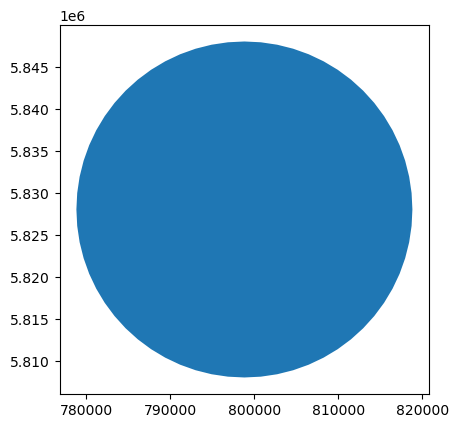

In [9]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from rasterio.mask import mask 
import rasterio

crs = 'EPSG:25832'

berlin = Point(13.40500, 52.52000)
gdf_berlin = gpd.GeoDataFrame([berlin], columns = ['geometry'])
gdf_berlin.crs = 4326
gdf_berlin = gdf_berlin.to_crs(crs)
gdf_berlin = gdf_berlin.buffer(20000)
gdf_berlin.plot()

In [11]:
raster_file = 'germany_population_reprojected.tif'

In [12]:
with rasterio.open(raster_file) as src:

    geom = [gdf_berlin.geometry][0]
    out_image_masked, out_transform_masked = mask(src, geom, crop=True)
    out_image_masked = out_image_masked[0]
    valid_data = out_image_masked[out_image_masked != src.nodata]  

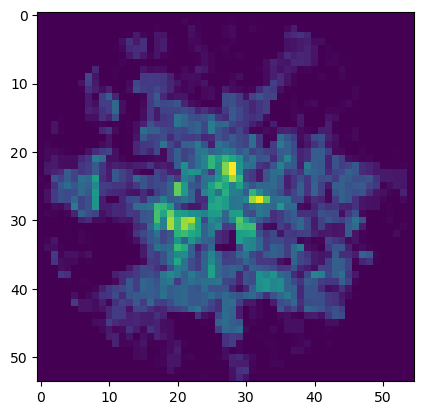

In [13]:
plt.imshow(out_image_masked)

(array([1965.,  349.,  299.,  205.,   60.,   49.,   22.,    9.,    9.,
           3.]),
 array([    0.        ,  1159.38270346,  2318.76540693,  3478.14811039,
         4637.53081385,  5796.91351732,  6956.29622078,  8115.67892424,
         9275.06162771, 10434.44433117, 11593.82703463]),
 <BarContainer object of 10 artists>)

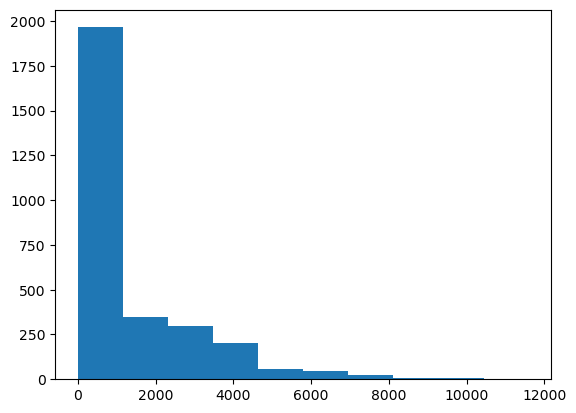

In [14]:
plt.hist(out_image_masked.flatten())

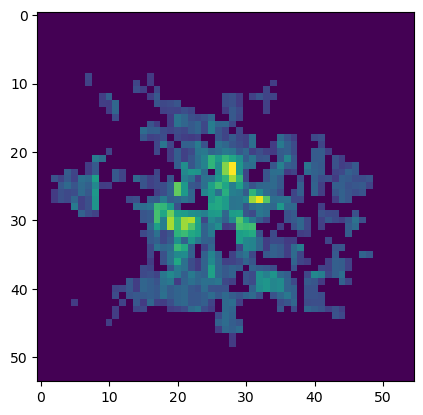

In [15]:
import numpy as np

threshold = 2000
out_image_masked_urban = np.where(out_image_masked > threshold, out_image_masked, 0)

plt.imshow(out_image_masked_urban)